In [ ]:
from google.colab import drive, files as colab_files
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:

!pip install 'git+https://github.com/facebookresearch/detectron2.git'

  Cloning https://github.com/facebookresearch/detectron2.git to /tmp/pip-req-build-36kgpkxv
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/detectron2.git /tmp/pip-req-build-36kgpkxv
  Resolved https://github.com/facebookresearch/detectron2.git to commit 02b5c4e295e990042a714712c21dc79b731e8833
  Preparing metadata (setup.py) ... done


In [ ]:
import os, json, random, shutil
import pandas as pd
import numpy as np
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt

TRAINING_DATA_PATH = "/content/drive/MyDrive/Newspaper_Project/trainingData"
OUTPUT_PATH        = "/content/drive/MyDrive/Newspaper_Project"
COCO_OUT           = "/content/drive/MyDrive/Newspaper_Project/coco_dataset"

os.makedirs(f"{COCO_OUT}/annotations", exist_ok=True)
os.makedirs(f"{COCO_OUT}/images",      exist_ok=True)

LABEL_MAP = {1: "article", 2: "ads", 3: "headline"}
print("Done")

Done


In [ ]:
records = []

for folder_name in sorted(os.listdir(TRAINING_DATA_PATH)):
    folder_path = os.path.join(TRAINING_DATA_PATH, folder_name)

    if not os.path.isdir(folder_path):
        continue

    csv_file = jpg_file = None
    for f in os.listdir(folder_path):
        if f.lower().endswith(".csv"):
            csv_file = f
        elif f.lower().endswith((".jpg", ".jpeg", ".png")):
            jpg_file = f

    if csv_file is None or jpg_file is None:
        print(f"  Skip... '{folder_name}' missing csv or image")
        continue

    df_tmp = pd.read_csv(os.path.join(folder_path, csv_file))
    df_tmp["image_path"] = os.path.join(folder_path, jpg_file)  # ← full path
    df_tmp["image_name"] = jpg_file
    df_tmp["folder"]     = folder_name
    records.append(df_tmp)

df_all = pd.concat(records, ignore_index=True)

print(f"✓ {len(df_all)} annotations | {df_all['image_name'].nunique()} images")
print(f"Columns: {df_all.columns.tolist()}")
print(df_all[["image_name","image_path"]].head(3))

✓ 1344 annotations | 151 images
Columns: ['x1', 'y1', 'x2', 'y2', 'label', 'width', 'height', 'area', 'image_name', 'image_path', 'folder']
                                          image_name  \
0  THE HINDU HD Delhi Editable Full Edition 02~05...   
1  THE HINDU HD Delhi Editable Full Edition 02~05...   
2  THE HINDU HD Delhi Editable Full Edition 02~05...   

                                          image_path  
0  /content/drive/MyDrive/Newspaper_Project/train...  
1  /content/drive/MyDrive/Newspaper_Project/train...  
2  /content/drive/MyDrive/Newspaper_Project/train...  


In [ ]:
#visualisation

VIZ_COLORS = {1: "blue", 2: "red", 3: "green"}
train_imgs = set(df_all["image_name"].unique()[:int(len(df_all["image_name"].unique())*0.8)])
N_SAMPLES = 3
sample_names = random.sample(list(train_imgs), min(N_SAMPLES, len(train_imgs)))

fig, axes = plt.subplots(1, len(sample_names),
                         figsize=(7 * len(sample_names), 10))
if len(sample_names) == 1:
    axes = [axes]

for ax, img_name in zip(axes, sample_names):

    img_path = df_all[df_all["image_name"] == img_name]["image_path"].iloc[0]

    print(f"Opening: {img_path}")

    img  = Image.open(img_path).convert("RGB")
    draw = ImageDraw.Draw(img)

    rows = df_all[df_all["image_name"] == img_name]
    for _, row in rows.iterrows():
        x1, y1, x2, y2 = row["x1"], row["y1"], row["x2"], row["y2"]
        label_id   = int(row["label"])
        color      = VIZ_COLORS.get(label_id, "white")
        label_name = LABEL_MAP.get(label_id, "?")

        draw.rectangle([x1, y1, x2, y2], outline=color, width=5)
        draw.rectangle([x1, y1, x1+120, y1+24], fill=color)
        draw.text((x1+4, y1+4), label_name, fill="white")

    ax.imshow(np.array(img))
    ax.set_title(img_name[:40], fontsize=8)
    ax.axis("off")

plt.suptitle("Blue=article  |  Red=ads  |  Green=headline", fontsize=10, y=1.01)
plt.tight_layout()
plt.savefig("/content/annotation_check.png", dpi=80, bbox_inches="tight")
plt.show()
print("✓ Done — check boxes above")

Output hidden; open in https://colab.research.google.com to view.

In [ ]:

import torch
import detectron2
from detectron2.utils.logger import setup_logger
setup_logger()

from detectron2.data import DatasetCatalog, MetadataCatalog
from detectron2.data.datasets import register_coco_instances
from detectron2.utils.visualizer import Visualizer

print(f"PyTorch     : {torch.__version__}")
print(f"CUDA        : {torch.cuda.is_available()}")
print(f"GPU         : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")
print(f"Detectron2  : {detectron2.__version__}")

PyTorch     : 2.11.0+cu128
CUDA        : True
GPU         : Tesla T4
Detectron2  : 0.6


In [ ]:

import json

# COCO_OUT   = "/content/drive/MyDrive/Newspaper_Project/coco_dataset"
TRAIN_JSON = f"{COCO_OUT}/annotations/train.json"
VAL_JSON   = f"{COCO_OUT}/annotations/val.json"

path_lookup = dict(zip(df_all["image_name"], df_all["image_path"]))

print(f"Total images in lookup: {len(path_lookup)}")
print(f"Example entry:")
sample_key = list(path_lookup.keys())[0]
print(f"  {sample_key[:40]}")
print(f"  → {path_lookup[sample_key]}")

Total images in lookup: 151
Example entry:
  THE HINDU HD Delhi Editable Full Edition
  → /content/drive/MyDrive/Newspaper_Project/trainingData/TH1 - Copy (15)/THE HINDU HD Delhi Editable Full Edition 02~05~2026_page-0006.jpg


In [ ]:

import json, random
from PIL import Image

def build_coco_json(df, output_path):
    images, annotations, ann_id = [], [], 1

    for img_id, (img_name, group) in enumerate(df.groupby("image_name"), start=1):
        img_path = group["image_path"].iloc[0]
        with Image.open(img_path) as im:
            w, h = im.size

        images.append({
            "id": img_id,
            "file_name": img_path,
            "width": w,
            "height": h
        })

        for _, row in group.iterrows():
            x1, y1, x2, y2 = row["x1"], row["y1"], row["x2"], row["y2"]
            bw, bh = x2 - x1, y2 - y1
            annotations.append({
                "id": ann_id,
                "image_id": img_id,
                "category_id": int(row["label"]),
                "bbox": [x1, y1, bw, bh],
                "area": bw * bh,
                "iscrowd": 0
            })
            ann_id += 1

    coco = {
        "images": images,
        "annotations": annotations,
        "categories": [
            {"id": 1, "name": "article"},
            {"id": 2, "name": "ads"},
            {"id": 3, "name": "headline"}
        ]
    }

    with open(output_path, "w") as f:
        json.dump(coco, f, indent=2)
    print(f"✓ Saved {len(images)} images, {len(annotations)} annotations → {output_path.split('/')[-1]}")

# 80/20

In [ ]:

# def fix_json_paths(json_path):
#     with open(json_path, "r") as f:
#         coco = json.load(f)

#     fixed = 0
#     for img in coco["images"]:
#         fname = img["file_name"]
#         if fname in path_lookup:
#             img["file_name"] = path_lookup[fname]
#             fixed += 1
#         else:
#             print(f"Not found: {fname[:50]}")

#     with open(json_path, "w") as f:
#         json.dump(coco, f, indent=2)

#     print(f"✓ {json_path.split('/')[-1]} — fixed {fixed} paths")

# fix_json_paths(TRAIN_JSON)
# fix_json_paths(VAL_JSON)

In [ ]:
import json, random
from PIL import Image

def build_coco_json(df, output_path):
    images, annotations, ann_id = [], [], 1

    for img_id, (img_name, group) in enumerate(df.groupby("image_name"), start=1):
        img_path = group["image_path"].iloc[0]
        with Image.open(img_path) as im:
            w, h = im.size

        images.append({
            "id": img_id,
            "file_name": img_path,
            "width": w,
            "height": h
        })

        for _, row in group.iterrows():
            x1, y1, x2, y2 = float(row["x1"]), float(row["y1"]), float(row["x2"]), float(row["y2"])
            bw, bh = x2 - x1, y2 - y1
            annotations.append({
                "id": ann_id,
                "image_id": img_id,
                "category_id": int(row["label"]),
                "bbox": [x1, y1, bw, bh],
                "area": bw * bh,
                "iscrowd": 0
            })
            ann_id += 1

    coco = {
        "images": images,
        "annotations": annotations,
        "categories": [
            {"id": 1, "name": "article"},
            {"id": 2, "name": "ads"},
            {"id": 3, "name": "headline"}
        ]
    }

    with open(output_path, "w") as f:
        json.dump(coco, f, indent=2)
    print(f"✓ {len(images)} images, {ann_id-1} annotations → {output_path.split('/')[-1]}")

# 80/20 split
all_images = df_all["image_name"].unique().tolist()
random.shuffle(all_images)
split = int(0.8 * len(all_images))
train_names = set(all_images[:split])
val_names   = set(all_images[split:])

df_train = df_all[df_all["image_name"].isin(train_names)]
df_val   = df_all[df_all["image_name"].isin(val_names)]

print(f"Train: {len(train_names)} images | Val: {len(val_names)} images")

build_coco_json(df_train, TRAIN_JSON)
build_coco_json(df_val,   VAL_JSON)

Train: 120 images | Val: 31 images
✓ 120 images, 1089 annotations → train.json
✓ 31 images, 255 annotations → val.json


In [ ]:
# CELL 7 — Register dataset with Detectron2

from detectron2.data import DatasetCatalog, MetadataCatalog
from detectron2.data.datasets import register_coco_instances

for name in ["newspaper_train", "newspaper_val"]:
    if name in DatasetCatalog.list():
        DatasetCatalog.remove(name)
        MetadataCatalog.remove(name)

register_coco_instances("newspaper_train", {}, TRAIN_JSON, image_root="")
register_coco_instances("newspaper_val",   {}, VAL_JSON,   image_root="")

MetadataCatalog.get("newspaper_train").thing_classes = ["article", "ads", "headline"]
MetadataCatalog.get("newspaper_val").thing_classes   = ["article", "ads", "headline"]

print("Registered:", DatasetCatalog.list())
print("Classes:", MetadataCatalog.get("newspaper_train").thing_classes)

Registered: ['coco_2014_train', 'coco_2014_val', 'coco_2014_minival', 'coco_2014_valminusminival', 'coco_2017_train', 'coco_2017_val', 'coco_2017_test', 'coco_2017_test-dev', 'coco_2017_val_100', 'keypoints_coco_2014_train', 'keypoints_coco_2014_val', 'keypoints_coco_2014_minival', 'keypoints_coco_2014_valminusminival', 'keypoints_coco_2017_train', 'keypoints_coco_2017_val', 'keypoints_coco_2017_val_100', 'coco_2017_train_panoptic_separated', 'coco_2017_train_panoptic_stuffonly', 'coco_2017_train_panoptic', 'coco_2017_val_panoptic_separated', 'coco_2017_val_panoptic_stuffonly', 'coco_2017_val_panoptic', 'coco_2017_val_100_panoptic_separated', 'coco_2017_val_100_panoptic_stuffonly', 'coco_2017_val_100_panoptic', 'lvis_v1_train', 'lvis_v1_val', 'lvis_v1_test_dev', 'lvis_v1_test_challenge', 'lvis_v0.5_train', 'lvis_v0.5_val', 'lvis_v0.5_val_rand_100', 'lvis_v0.5_test', 'lvis_v0.5_train_cocofied', 'lvis_v0.5_val_cocofied', 'cityscapes_fine_instance_seg_train', 'cityscapes_fine_sem_seg_trai

In [ ]:
import os, json

COCO_OUT   = "/content/drive/MyDrive/Newspaper_Project/coco_dataset"
TRAIN_JSON = f"{COCO_OUT}/annotations/train.json"
VAL_JSON   = f"{COCO_OUT}/annotations/val.json"

ann_dir = f"{COCO_OUT}/annotations"
print("Annotations folder exists:", os.path.exists(ann_dir))

print("train.json exists:", os.path.exists(TRAIN_JSON))
print("val.json exists:  ", os.path.exists(VAL_JSON))

try:
    print("df_all shape:", df_all.shape)
    print("Sample image_path:", df_all['image_path'].iloc[0])
except NameError:
    print("❌ df_all not defined — rerun the data loading cell first")

Annotations folder exists: True
train.json exists: True
val.json exists:   True
df_all shape: (1344, 11)
Sample image_path: /content/drive/MyDrive/Newspaper_Project/trainingData/TH 26/THE HINDU HD Delhi Editable Full Edition 02~05~2026_page-0006.jpg


In [ ]:
# verification

import cv2
import random
import matplotlib.pyplot as plt

dataset_dicts = DatasetCatalog.get("newspaper_train")
metadata      = MetadataCatalog.get("newspaper_train")

print(f"Total train samples: {len(dataset_dicts)}")
print(f"\nFirst sample:")
d = dataset_dicts[0]
print(f"  file_name : {d['file_name'].split('/')[-1]}")
print(f"  size      : {d['width']} x {d['height']}")
print(f"  boxes     : {len(d['annotations'])}")

[06/27 07:23:18 d2.data.datasets.coco]: Loaded 120 images in COCO format from /content/drive/MyDrive/Newspaper_Project/coco_dataset/annotations/train.json
Total train samples: 120

First sample:
  file_name : TH 26--2025 Delhi-page-001.jpg
  size      : 3300 x 5100
  boxes     : 6


In [ ]:

import cv2

d = dataset_dicts[0]

print(f"JSON says    : {d['width']} x {d['height']}")

img = cv2.imread(d["file_name"])
if img is not None:
    actual_h, actual_w = img.shape[:2]
    print(f"Actual image : {actual_w} x {actual_h}")

    if d['width'] != actual_w or d['height'] != actual_h:
        print("MISMATCH — bounding boxes will be wrong!")
    else:
        print("Sizes match — all good")
else:
    print("Could not open image — check path")
    print(f"Path tried: {d['file_name']}")

JSON says    : 3300 x 5100
Actual image : 3300 x 5100
Sizes match — all good


In [ ]:

import json
from PIL import Image

def fix_image_sizes(json_path):
    with open(json_path, "r") as f:
        coco = json.load(f)

    fixed = 0
    for img_entry in coco["images"]:
        try:
            with Image.open(img_entry["file_name"]) as im:
                real_w, real_h = im.size
            img_entry["width"]  = real_w
            img_entry["height"] = real_h
            fixed += 1
        except Exception as e:
            print(f"Could not open: {img_entry['file_name'].split('/')[-1]} — {e}")

    with open(json_path, "w") as f:
        json.dump(coco, f, indent=2)

    print(f"✓ Fixed dimensions for {fixed} images in {json_path.split('/')[-1]}")

fix_image_sizes(TRAIN_JSON)
fix_image_sizes(VAL_JSON)

✓ Fixed dimensions for 120 images in train.json
✓ Fixed dimensions for 31 images in val.json


In [ ]:
# Re-register with fixed JSONs

for name in ["newspaper_train", "newspaper_val"]:
    if name in DatasetCatalog.list():
        DatasetCatalog.remove(name)
        MetadataCatalog.remove(name)

register_coco_instances("newspaper_train", {}, TRAIN_JSON, image_root="")
register_coco_instances("newspaper_val",   {}, VAL_JSON,   image_root="")

MetadataCatalog.get("newspaper_train").thing_classes = ["article", "ads", "headline"]
MetadataCatalog.get("newspaper_val").thing_classes   = ["article", "ads", "headline"]

# Verify size now
dataset_dicts = DatasetCatalog.get("newspaper_train")
d = dataset_dicts[0]
print(f"JSON says    : {d['width']} x {d['height']}")

img = cv2.imread(d["file_name"])
actual_h, actual_w = img.shape[:2]
print(f"Actual image : {actual_w} x {actual_h}")

if d['width'] == actual_w and d['height'] == actual_h:
    print("✓ Sizes match — ready to visualize!")
else:
    print("⚠️  Still mismatched")

[06/27 07:23:52 d2.data.datasets.coco]: Loaded 120 images in COCO format from /content/drive/MyDrive/Newspaper_Project/coco_dataset/annotations/train.json
JSON says    : 3300 x 5100
Actual image : 3300 x 5100
✓ Sizes match — ready to visualize!


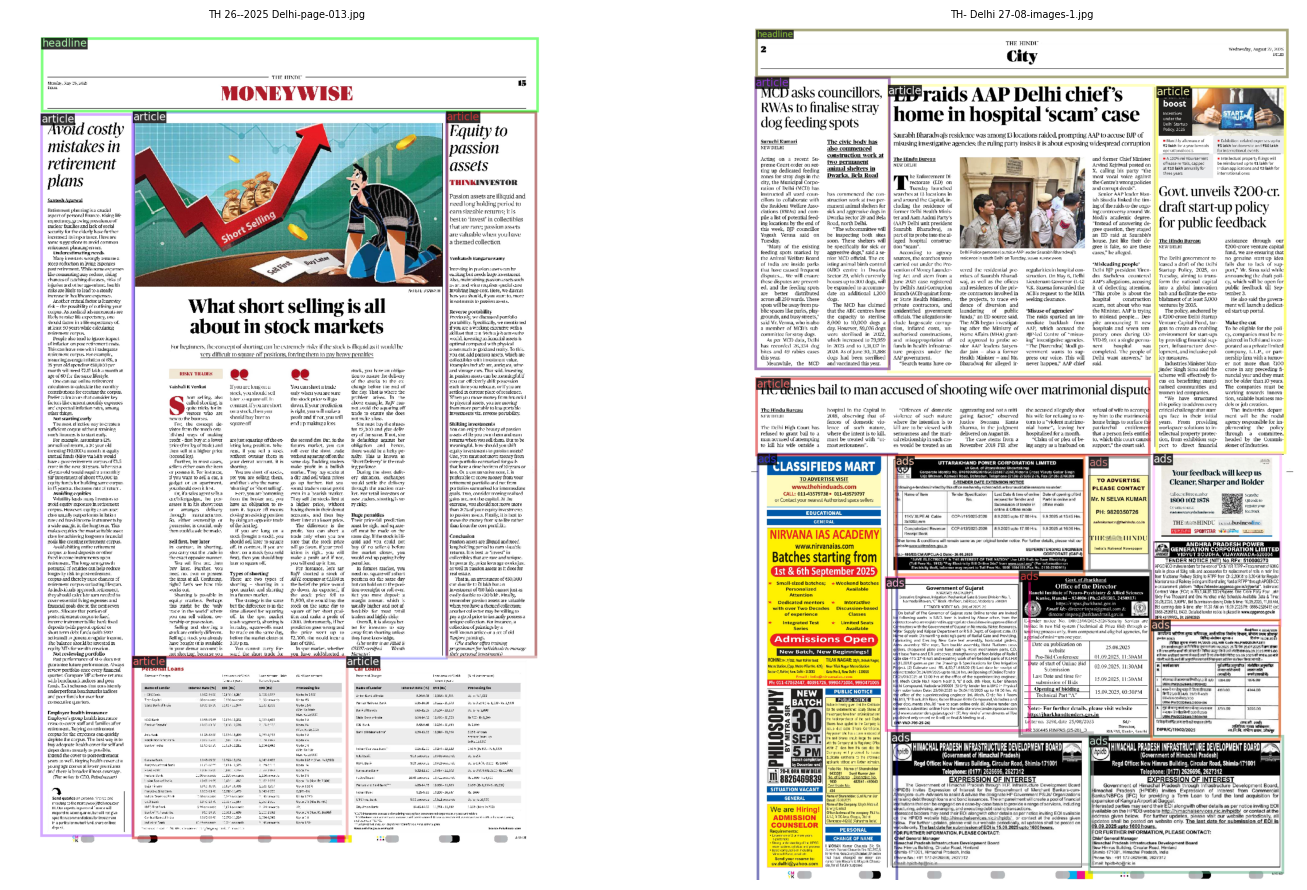

In [ ]:
# Detectron2 visualization

fig, axes = plt.subplots(1, 2, figsize=(16, 9))
samples = random.sample(dataset_dicts, 2)

for ax, d in zip(axes, samples):
    img = cv2.imread(d["file_name"])
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    v = Visualizer(img_rgb, metadata=metadata, scale=0.3)
    out = v.draw_dataset_dict(d)

    ax.imshow(out.get_image())
    ax.set_title(d["file_name"].split("/")[-1][:40], fontsize=7)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# TRAINING CELL (Faster R-CNN... fine-tuned on newspaper layout)

from detectron2.engine import DefaultTrainer
from detectron2.config import get_cfg
from detectron2 import model_zoo
import os

OUTPUT_DIR = "/content/drive/MyDrive/Newspaper_Project/model_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

cfg = get_cfg()

# Faster R-CNN with ResNet-50
cfg.merge_from_file(model_zoo.get_config_file(
    "COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml"
))

# Datasets
cfg.DATASETS.TRAIN = ("newspaper_train",)
cfg.DATASETS.TEST  = ("newspaper_val",)

# Pretrained weights
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url(
    "COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml"
)

# DataLoader
cfg.DATALOADER.NUM_WORKERS = 2

# Training hyperparameters
cfg.SOLVER.IMS_PER_BATCH   = 2
cfg.SOLVER.BASE_LR         = 0.00025
cfg.SOLVER.MAX_ITER        = 3000
cfg.SOLVER.STEPS           = (2000, 2500)   # LR decay points
cfg.SOLVER.GAMMA           = 0.1
cfg.SOLVER.CHECKPOINT_PERIOD = 500

# Model
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 3

# Output
cfg.OUTPUT_DIR = OUTPUT_DIR

# Evaluation period
cfg.TEST.EVAL_PERIOD = 500

trainer = DefaultTrainer(cfg)
trainer.resume_or_load(resume=False)
trainer.train()

[06/27 07:28:39 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res

model_final_280758.pkl: 167MB [00:02, 73.3MB/s]                           
roi_heads.box_predictor.bbox_pred.{bias, weight}
roi_heads.box_predictor.cls_score.{bias, weight}


[06/27 07:28:41 d2.engine.train_loop]: Starting training from iteration 0


/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
W0627 07:28:49.576000 552 torch/fx/_symbolic_trace.py:53] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.


[06/27 07:29:28 d2.utils.events]:  eta: 1:45:01  iter: 19  total_loss: 3.03  loss_cls: 1.301  loss_box_reg: 0.1721  loss_rpn_cls: 1.293  loss_rpn_loc: 0.2061    time: 2.0776  last_time: 3.1164  data_time: 1.6142  last_data_time: 2.5540   lr: 4.9953e-06  max_mem: 2480M
[06/27 07:30:11 d2.utils.events]:  eta: 1:38:30  iter: 39  total_loss: 2.455  loss_cls: 1.234  loss_box_reg: 0.1807  loss_rpn_cls: 0.7491  loss_rpn_loc: 0.1637    time: 1.9837  last_time: 0.5931  data_time: 1.4100  last_data_time: 0.1781   lr: 9.9902e-06  max_mem: 2481M
[06/27 07:30:52 d2.utils.events]:  eta: 1:38:28  iter: 59  total_loss: 1.913  loss_cls: 1.115  loss_box_reg: 0.3461  loss_rpn_cls: 0.155  loss_rpn_loc: 0.1516    time: 2.0013  last_time: 1.3457  data_time: 1.5484  last_data_time: 0.9073   lr: 1.4985e-05  max_mem: 2481M
[06/27 07:31:22 d2.utils.events]:  eta: 1:29:59  iter: 79  total_loss: 1.573  loss_cls: 0.9616  loss_box_reg: 0.4108  loss_rpn_cls: 0.0895  loss_rpn_loc: 0.1383    time: 1.8820  last_time: 1

In [ ]:
import os

OUTPUT_DIR = "/content/drive/MyDrive/Newspaper_Project/model_output"

files = os.listdir(OUTPUT_DIR)
files.sort()
for f in files:
    size = os.path.getsize(os.path.join(OUTPUT_DIR, f)) / (1024*1024)
    print(f"{f}  —  {size:.1f} MB")

FINAL_MODEL = os.path.join(OUTPUT_DIR, "model_final.pth")
print(f"\nFinal model exists: {os.path.exists(FINAL_MODEL)}")

events.out.tfevents.1782545373.4a93df4bc493.552.0  —  0.1 MB
last_checkpoint  —  0.0 MB
metrics.json  —  0.1 MB
model_0000499.pth  —  314.8 MB
model_0000999.pth  —  314.8 MB
model_0001499.pth  —  314.8 MB
model_0001999.pth  —  314.8 MB
model_0002499.pth  —  314.8 MB
model_0002999.pth  —  314.8 MB
model_final.pth  —  314.8 MB

Final model exists: True


In [ ]:
import cv2
import random
import torch
import matplotlib.pyplot as plt
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2.utils.visualizer import Visualizer, ColorMode
from detectron2 import model_zoo
from torchvision.ops import nms

# Config
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file(
    "COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml"
))
cfg.DATASETS.TRAIN = ("newspaper_train",)
cfg.DATASETS.TEST  = ("newspaper_val",)
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 3
cfg.MODEL.WEIGHTS  = os.path.join(OUTPUT_DIR, "model_final.pth")

# KEY FIXES
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.7
cfg.MODEL.ROI_HEADS.NMS_THRESH_TEST   = 0.3
cfg.TEST.DETECTIONS_PER_IMAGE         = 100

predictor = DefaultPredictor(cfg)
metadata  = MetadataCatalog.get("newspaper_train")

def clean_instances(instances, iou_threshold=0.3):
    """ to remove any remaining overlaps"""
    if len(instances) == 0:
        return instances

    boxes   = instances.pred_boxes.tensor
    scores  = instances.scores
    classes = instances.pred_classes

    keep_indices = []
    for cls_id in classes.unique():
        cls_mask = (classes == cls_id)
        cls_boxes  = boxes[cls_mask]
        cls_scores = scores[cls_mask]
        cls_keep   = nms(cls_boxes, cls_scores, iou_threshold)

        orig_indices = cls_mask.nonzero(as_tuple=True)[0]
        keep_indices.extend(orig_indices[cls_keep].tolist())

    keep_indices = sorted(set(keep_indices))
    return instances[keep_indices]

dataset_dicts = DatasetCatalog.get("newspaper_val")
samples = random.sample(dataset_dicts, 4)

fig, axes = plt.subplots(2, 2, figsize=(20, 24))
axes = axes.flatten()

for ax, d in zip(axes, samples):
    img     = cv2.imread(d["file_name"])
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    outputs   = predictor(img)
    instances = outputs["instances"].to("cpu")

    instances = clean_instances(instances, iou_threshold=0.3)

    print(f"\n{d['file_name'].split('/')[-1]}")
    print(f"  Detected {len(instances)} objects after cleanup")
    print(f"  Classes : {instances.pred_classes.tolist()}")
    print(f"  Scores  : {[round(s,2) for s in instances.scores.tolist()]}")

    v = Visualizer(img_rgb, metadata=metadata, scale=0.3,
                   instance_mode=ColorMode.SEGMENTATION)
    out = v.draw_instance_predictions(instances)

    ax.imshow(out.get_image())
    ax.set_title(d["file_name"].split("/")[-1][:40], fontsize=8)
    ax.axis("off")

plt.suptitle("Inference Results (cleaned) — article | ads | headline",
             fontsize=12, y=1.01)
plt.tight_layout()

INFERENCE_OUT = "/content/drive/MyDrive/Newspaper_Project/inference_results_clean.png"
plt.savefig(INFERENCE_OUT, dpi=80, bbox_inches="tight")
plt.show()
print(f"\n✓ Saved to {INFERENCE_OUT}")

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
from detectron2.evaluation import COCOEvaluator, inference_on_dataset
from detectron2.data import build_detection_test_loader
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2 import model_zoo
import os

# Config — same as training
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file(
    "COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml"
))
cfg.DATASETS.TRAIN = ("newspaper_train",)
cfg.DATASETS.TEST  = ("newspaper_val",)
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 3
cfg.MODEL.WEIGHTS  = os.path.join(OUTPUT_DIR, "model_final.pth")
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5
cfg.MODEL.ROI_HEADS.NMS_THRESH_TEST   = 0.3
cfg.TEST.DETECTIONS_PER_IMAGE = 100

predictor = DefaultPredictor(cfg)

evaluator = COCOEvaluator(
    dataset_name="newspaper_val",
    output_dir=os.path.join(OUTPUT_DIR, "eval")
)

val_loader = build_detection_test_loader(cfg, "newspaper_val")

# Run evaluation
print("Running evaluation on val set (31 images)...")
results = inference_on_dataset(predictor.model, val_loader, evaluator)

print("\n========== FINAL RESULTS ==========")
print(results)

[06/27 09:09:12 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /content/drive/MyDrive/Newspaper_Project/model_output/model_final.pth ...
[06/27 09:09:16 d2.data.datasets.coco]: Loaded 31 images in COCO format from /content/drive/MyDrive/Newspaper_Project/coco_dataset/annotations/val.json
[06/27 09:09:16 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(800, 800), max_size=1333, sample_style='choice')]
[06/27 09:09:16 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[06/27 09:09:16 d2.data.common]: Serializing 31 elements to byte tensors and concatenating them all ...
[06/27 09:09:16 d2.data.common]: Serialized dataset takes 0.02 MiB
Running evaluation on val set (31 images)...
[06/27 09:09:16 d2.evaluation.evaluator]: Start inference on 31 batches


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


[06/27 09:09:24 d2.evaluation.evaluator]: Inference done 11/31. Dataloading: 0.0641 s/iter. Inference: 0.1296 s/iter. Eval: 0.0004 s/iter. Total: 0.1941 s/iter. ETA=0:00:03
[06/27 09:09:31 d2.evaluation.evaluator]: Inference done 17/31. Dataloading: 0.5361 s/iter. Inference: 0.1477 s/iter. Eval: 0.0004 s/iter. Total: 0.6845 s/iter. ETA=0:00:09
[06/27 09:09:36 d2.evaluation.evaluator]: Inference done 24/31. Dataloading: 0.5623 s/iter. Inference: 0.1453 s/iter. Eval: 0.0010 s/iter. Total: 0.7089 s/iter. ETA=0:00:04
[06/27 09:09:41 d2.evaluation.evaluator]: Total inference time: 0:00:18.045432 (0.694055 s / iter per device, on 1 devices)
[06/27 09:09:41 d2.evaluation.evaluator]: Total inference pure compute time: 0:00:03 (0.141456 s / iter per device, on 1 devices)
[06/27 09:09:41 d2.evaluation.coco_evaluation]: Preparing results for COCO format ...
[06/27 09:09:41 d2.evaluation.coco_evaluation]: Saving results to /content/drive/MyDrive/Newspaper_Project/model_output/eval/coco_instances_r

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install 'git+https://github.com/facebookresearch/detectron2.git' --quiet

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 4.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.1/95.1 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 91.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.8/269.8 kB 31.3 MB/s eta 0:00:00


In [ ]:
import os
from detectron2.config import get_cfg
from detectron2 import model_zoo

cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file(
    "COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml"
))
cfg.MODEL.ROI_HEADS.NUM_CLASSES           = 3
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST     = 0.7
cfg.MODEL.ROI_HEADS.NMS_THRESH_TEST       = 0.3
cfg.TEST.DETECTIONS_PER_IMAGE             = 100

EXPORT_DIR = "/content/drive/MyDrive/Newspaper_Project/model_output"
os.makedirs(EXPORT_DIR, exist_ok=True)

with open(os.path.join(EXPORT_DIR, "config.yaml"), "w") as f:
    f.write(cfg.dump())

print("✓ config.yaml saved")
print(os.listdir(EXPORT_DIR))

✓ config.yaml saved
['model_0000499.pth', 'model_0000999.pth', 'model_0001499.pth', 'model_0001999.pth', 'model_0002499.pth', 'model_0002999.pth', 'model_final.pth', 'metrics.json', 'events.out.tfevents.1782545373.4a93df4bc493.552.0', 'last_checkpoint', 'eval', 'config.yaml']
